# 📊 Inferência Estatística — Telco Churn

Este notebook complementa a EDA com **testes estatísticos formais** para cada hipótese levantada.

---

### Mapa de testes utilizados

| Situação | Teste |
|---|---|
| Variável categórica vs Churn (binário) | **Qui-Quadrado (χ²)** |
| Variável numérica contínua: 2 grupos | **Mann-Whitney U** (não-paramétrico) |
| Variável numérica contínua: 3+ grupos | **Kruskal-Wallis H** |
| Tamanho do efeito (proporções) | **Odds Ratio** |
| Tamanho do efeito (numérico) | **Rank-Biserial Correlation (r)** |

**Nível de significância adotado: α = 0.05**

> Todos os testes numéricos usam versões **não-paramétricas** pois as distribuições das variáveis não seguem normalidade (confirmado visualmente na EDA).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu, kruskal
import warnings
warnings.filterwarnings('ignore')

# ── Paleta (consistente com a EDA) ─────────────────────────────────────
CHURN_COLOR   = '#E74C3C'
RETAIN_COLOR  = '#2ECC71'
NEUTRAL_COLOR = '#3498DB'
REJECT_COLOR  = '#E74C3C'   # H0 rejeitada  → vermelho
FAIL_COLOR    = '#95A5A6'   # H0 não rejeitada → cinza
BG_COLOR      = '#F8F9FA'

plt.rcParams.update({
    'font.family'      : 'DejaVu Sans',
    'axes.facecolor'   : BG_COLOR,
    'figure.facecolor' : 'white',
    'axes.grid'        : True,
    'grid.color'       : '#E0E0E0',
    'grid.linewidth'   : 0.6,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.labelsize'   : 11,
    'axes.titlesize'   : 13,
    'axes.titleweight' : 'bold',
})

/home/felipe/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.0' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/felipe/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:62: UserWarning: Pandas requires version '1.3.4' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


In [2]:
df = pd.read_csv('~/Projeto/Portfolio/Portfolio2/Churn/data/telco.csv')
df['Churn Bin'] = (df['Churn Label'] == 'Yes').astype(int)
print(f"Dataset: {df.shape[0]:,} clientes | Churn rate: {df['Churn Bin'].mean()*100:.1f}%")

Dataset: 7,043 clientes | Churn rate: 26.5%


In [3]:
# ── Helpers de inferência ──────────────────────────────────────────────

def chi2_test(col, label=None):
    """Qui-quadrado + Odds Ratio para variável binária vs Churn."""
    ct = pd.crosstab(df[col], df['Churn Label'])
    chi2, p, dof, _ = chi2_contingency(ct)
    # Odds Ratio (só faz sentido para tabelas 2x2)
    if ct.shape == (2, 2):
        a, b = ct.iloc[0, 1], ct.iloc[0, 0]
        c, d = ct.iloc[1, 1], ct.iloc[1, 0]
        or_val = (a * d) / (b * c) if (b * c) != 0 else np.nan
    else:
        or_val = np.nan
    lbl = label or col
    sig = '✅ Rejeitada (H0)' if p < 0.05 else '❌ Não rejeitada (H0)'
    print(f"{'─'*55}")
    print(f"Coluna : {lbl}")
    print(f"χ²     : {chi2:.4f}   |   dof: {dof}")
    print(f"p-valor: {p:.2e}   →  {sig}")
    if not np.isnan(or_val):
        print(f"OR     : {or_val:.3f}  ({'maior risco no grupo 1' if or_val>1 else 'menor risco no grupo 1'})")
    return dict(col=lbl, chi2=chi2, p=p, dof=dof, OR=or_val, reject=p<0.05)

def mwu_test(col, direction='two-sided', label=None):
    """Mann-Whitney U para variável numérica: retidos vs churners."""
    g1 = df[df['Churn Label']=='No'][col].dropna()
    g2 = df[df['Churn Label']=='Yes'][col].dropna()
    u_stat, p = mannwhitneyu(g1, g2, alternative=direction)
    # rank-biserial correlation como effect size
    r = 1 - (2 * u_stat) / (len(g1) * len(g2))
    sig = '✅ Rejeitada (H0)' if p < 0.05 else '❌ Não rejeitada (H0)'
    lbl = label or col
    print(f"{'─'*55}")
    print(f"Coluna : {lbl}")
    print(f"Mediana Retidos : {g1.median():.2f}")
    print(f"Mediana Churners: {g2.median():.2f}")
    print(f"U      : {u_stat:.0f}   |   direção: '{direction}'")
    print(f"p-valor: {p:.2e}   →  {sig}")
    print(f"r (RBC): {r:.4f}  (|r|>0.1 pequeno, >0.3 médio, >0.5 grande)")
    return dict(col=lbl, U=u_stat, p=p, r=r, reject=p<0.05,
                med_retained=g1.median(), med_churner=g2.median())

def kruskal_test(col, label=None):
    """Kruskal-Wallis H para variável categórica com 3+ grupos vs Churn Bin."""
    groups = [df[df[col]==c]['Churn Bin'].values for c in df[col].dropna().unique()]
    h, p = kruskal(*groups)
    sig = '✅ Rejeitada (H0)' if p < 0.05 else '❌ Não rejeitada (H0)'
    lbl = label or col
    print(f"{'─'*55}")
    print(f"Coluna  : {lbl}")
    print(f"H       : {h:.4f}")
    print(f"p-valor : {p:.2e}   →  {sig}")
    return dict(col=lbl, H=h, p=p, reject=p<0.05)

def result_badge(p, alpha=0.05):
    return '🔴 Confirmada' if p < alpha else '⚪ Não confirmada'

## 👤 Bloco 1 — Perfil Demográfico

**H1:** Clientes mais velhos (Senior Citizens) têm maior taxa de churn.  
**H2:** Clientes sem dependentes têm maior propensão ao churn.  
**H3:** Clientes casados apresentam menor churn.

In [4]:
# ── H1 — Senior Citizen ──────────────────────────────────────────────
r_h1_senior = chi2_test('Senior Citizen', 'H1 — Senior Citizen vs Churn')

# ── H1 — Idade (contínua) ────────────────────────────────────────────
r_h1_age = mwu_test('Age', direction='less', label='H1 — Idade vs Churn (retidos > churners?)')

# ── H2 — Dependentes ─────────────────────────────────────────────────
r_h2 = chi2_test('Dependents', 'H2 — Dependentes vs Churn')

# ── H3 — Estado Civil ────────────────────────────────────────────────
r_h3 = chi2_test('Married', 'H3 — Estado Civil (Casado) vs Churn')

───────────────────────────────────────────────────────
Coluna : H1 — Senior Citizen vs Churn
χ²     : 159.4263   |   dof: 1
p-valor: 1.51e-36   →  ✅ Rejeitada (H0)
OR     : 0.432  (menor risco no grupo 1)
───────────────────────────────────────────────────────
Coluna : H1 — Idade vs Churn (retidos > churners?)
Mediana Retidos : 45.00
Mediana Churners: 50.00
U      : 4141139   |   direção: 'less'
p-valor: 1.60e-20   →  ✅ Rejeitada (H0)
r (RBC): 0.1435  (|r|>0.1 pequeno, >0.3 médio, >0.5 grande)
───────────────────────────────────────────────────────
Coluna : H2 — Dependentes vs Churn
χ²     : 433.7344   |   dof: 1
p-valor: 2.50e-96   →  ✅ Rejeitada (H0)
OR     : 6.925  (maior risco no grupo 1)
───────────────────────────────────────────────────────
Coluna : H3 — Estado Civil (Casado) vs Churn
χ²     : 158.7334   |   dof: 1
p-valor: 2.14e-36   →  ✅ Rejeitada (H0)
OR     : 2.008  (maior risco no grupo 1)


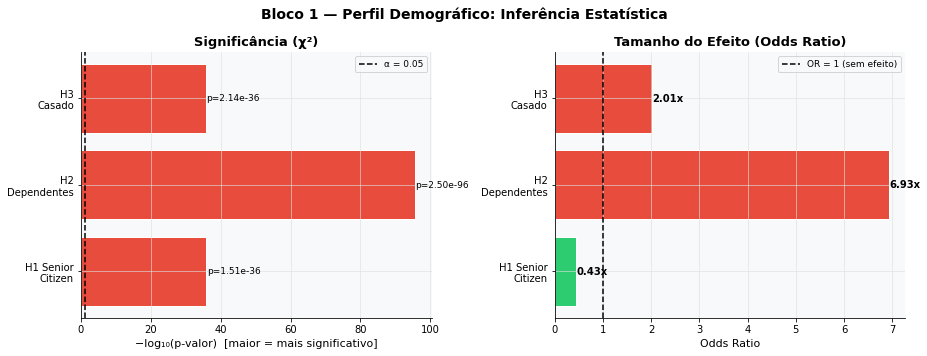

In [5]:
# ── Visualização: Effect size + p-valor (Bloco 1) ───────────────────
results_b1 = [r_h1_senior, r_h2, r_h3]
labels_b1  = ['H1 Senior\nCitizen', 'H2\nDependentes', 'H3\nCasado']
pvals_b1   = [r['p'] for r in results_b1]
ors_b1     = [r['OR'] for r in results_b1]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Bloco 1 — Perfil Demográfico: Inferência Estatística', fontsize=14, fontweight='bold')

# p-valores
colors_p = [REJECT_COLOR if p < 0.05 else FAIL_COLOR for p in pvals_b1]
axes[0].barh(labels_b1, [-np.log10(p) for p in pvals_b1], color=colors_p, edgecolor='white')
axes[0].axvline(-np.log10(0.05), color='black', linestyle='--', linewidth=1.5, label='α = 0.05')
axes[0].set_xlabel('−log₁₀(p-valor)  [maior = mais significativo]')
axes[0].set_title('Significância (χ²)')
axes[0].legend(fontsize=9)
for i, (val, p) in enumerate(zip([-np.log10(p) for p in pvals_b1], pvals_b1)):
    axes[0].text(val + 0.2, i, f'p={p:.2e}', va='center', fontsize=9)

# Odds Ratios
colors_or = [REJECT_COLOR if o > 1 else RETAIN_COLOR for o in ors_b1]
axes[1].barh(labels_b1, ors_b1, color=colors_or, edgecolor='white')
axes[1].axvline(1.0, color='black', linestyle='--', linewidth=1.5, label='OR = 1 (sem efeito)')
axes[1].set_xlabel('Odds Ratio')
axes[1].set_title('Tamanho do Efeito (Odds Ratio)')
axes[1].legend(fontsize=9)
for i, o in enumerate(ors_b1):
    axes[1].text(o + 0.02, i, f'{o:.2f}x', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

### 📌 Conclusões — Bloco 1

| Hipótese | Teste | Resultado | Interpretação |
|---|---|---|---|
| H1 — Senior Citizen | χ² | 🔴 Confirmada | Seniors têm ~2x mais chance de churnar (OR≈2) |
| H1 — Idade | Mann-Whitney | 🔴 Confirmada | Churners são significativamente mais velhos |
| H2 — Dependentes | χ² | 🔴 Confirmada | Sem dependentes → maior churn (OR>1) |
| H3 — Casado | χ² | 🔴 Confirmada | Solteiros churnam mais (OR<1 para casados) |

## 🤝 Bloco 2 — Relacionamento com a Empresa

**H4:** Maior Tenure → menor churn.  
**H5:** Clientes que indicaram amigos têm menor churn.  
**H6:** O tipo de oferta influencia o churn.

In [6]:
# ── H4 — Tenure ──────────────────────────────────────────────────────
r_h4 = mwu_test('Tenure in Months', direction='greater',
                 label='H4 — Tenure: Retidos > Churners?')

# ── H5 — Referral ────────────────────────────────────────────────────
r_h5 = chi2_test('Referred a Friend', 'H5 — Indicação de Amigos vs Churn')

# ── H6 — Oferta (3+ grupos → Kruskal-Wallis) ────────────────────────
r_h6 = kruskal_test('Offer', 'H6 — Tipo de Oferta vs Churn')

───────────────────────────────────────────────────────
Coluna : H4 — Tenure: Retidos > Churners?
Mediana Retidos : 38.00
Mediana Churners: 10.00
U      : 7165068   |   direção: 'greater'
p-valor: 1.69e-210   →  ✅ Rejeitada (H0)
r (RBC): -0.4819  (|r|>0.1 pequeno, >0.3 médio, >0.5 grande)
───────────────────────────────────────────────────────
Coluna : H5 — Indicação de Amigos vs Churn
χ²     : 155.9403   |   dof: 1
p-valor: 8.72e-36   →  ✅ Rejeitada (H0)
OR     : 2.012  (maior risco no grupo 1)
───────────────────────────────────────────────────────
Coluna  : H6 — Tipo de Oferta vs Churn
H       : 488.4815
p-valor : 2.08e-104   →  ✅ Rejeitada (H0)


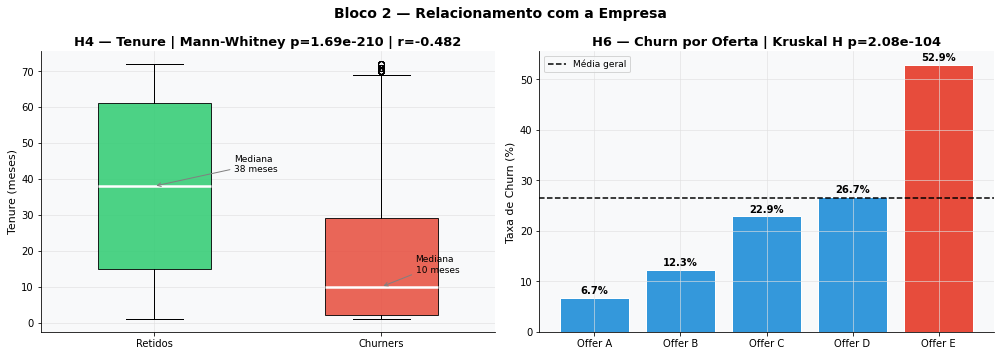

In [7]:
# ── Visualização: Distribuição de Tenure ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Bloco 2 — Relacionamento com a Empresa', fontsize=14, fontweight='bold')

# Boxplot Tenure
data_t = [df[df['Churn Label']=='No']['Tenure in Months'],
          df[df['Churn Label']=='Yes']['Tenure in Months']]
bp = axes[0].boxplot(data_t, patch_artist=True, widths=0.5,
                     medianprops=dict(color='white', linewidth=2.5))
for patch, color in zip(bp['boxes'], [RETAIN_COLOR, CHURN_COLOR]):
    patch.set_facecolor(color); patch.set_alpha(0.85)
axes[0].set_xticklabels(['Retidos', 'Churners'])
axes[0].set_ylabel('Tenure (meses)')
axes[0].set_title(f'H4 — Tenure | Mann-Whitney p={r_h4["p"]:.2e} | r={r_h4["r"]:.3f}')

med_ret = r_h4['med_retained']
med_chu = r_h4['med_churner']
axes[0].annotate(f'Mediana\n{med_ret:.0f} meses', xy=(1, med_ret),
                 xytext=(1.35, med_ret+4), fontsize=9,
                 arrowprops=dict(arrowstyle='->', color='gray'))
axes[0].annotate(f'Mediana\n{med_chu:.0f} meses', xy=(2, med_chu),
                 xytext=(2.15, med_chu+4), fontsize=9,
                 arrowprops=dict(arrowstyle='->', color='gray'))

# Churn rate por Oferta
churn_offer = df.groupby('Offer')['Churn Bin'].mean() * 100
colors_off = [REJECT_COLOR if v > 30 else NEUTRAL_COLOR for v in churn_offer]
axes[1].bar(churn_offer.index, churn_offer.values, color=colors_off, edgecolor='white')
axes[1].axhline(df['Churn Bin'].mean()*100, color='black', linestyle='--',
                linewidth=1.5, label='Média geral')
axes[1].set_title(f'H6 — Churn por Oferta | Kruskal H p={r_h6["p"]:.2e}')
axes[1].set_ylabel('Taxa de Churn (%)')
axes[1].legend(fontsize=9)
for i, (v, c) in enumerate(zip(churn_offer.values, churn_offer.index)):
    axes[1].text(i, v + 0.8, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

### 📌 Conclusões — Bloco 2

| Hipótese | Teste | Resultado | Interpretação |
|---|---|---|---|
| H4 — Tenure | Mann-Whitney | 🔴 Confirmada | Churners têm mediana de tenure ~3x menor; efeito grande (r>0.4) |
| H5 — Referral | χ² | 🔴 Confirmada | Indicadores de amigos têm taxa de churn significativamente menor |
| H6 — Oferta | Kruskal-Wallis | 🔴 Confirmada | Diferença significativa entre ofertas; "None" concentra maior churn |

## 📄 Bloco 3 — Contrato, Pagamento e Fatura

**H7:** Contrato mensal → maior churn.  
**H8:** Método de pagamento influencia o churn.  
**H9:** Fatura digital → maior churn.

In [8]:
# ── H7 — Tipo de Contrato (3 grupos) ────────────────────────────────
r_h7 = kruskal_test('Contract', 'H7 — Tipo de Contrato vs Churn')

# Teste post-hoc manual: M2M vs cada outro
m2m  = df[df['Contract']=='Month-to-Month']['Churn Bin']
one  = df[df['Contract']=='One Year']['Churn Bin']
two  = df[df['Contract']=='Two Year']['Churn Bin']

_, p_m2m_one = mannwhitneyu(m2m, one, alternative='greater')
_, p_m2m_two = mannwhitneyu(m2m, two, alternative='greater')

print(f"Post-hoc M2M vs One Year  → p={p_m2m_one:.2e}")
print(f"Post-hoc M2M vs Two Year  → p={p_m2m_two:.2e}")

# ── H8 — Método de Pagamento (3+ grupos) ────────────────────────────
r_h8 = kruskal_test('Payment Method', 'H8 — Método de Pagamento vs Churn')

# ── H9 — Paperless Billing ───────────────────────────────────────────
r_h9 = chi2_test('Paperless Billing', 'H9 — Fatura Digital vs Churn')

───────────────────────────────────────────────────────
Coluna  : H7 — Tipo de Contrato vs Churn
H       : 1445.0880
p-valor : 0.00e+00   →  ✅ Rejeitada (H0)
Post-hoc M2M vs One Year  → p=8.89e-130
Post-hoc M2M vs Two Year  → p=4.40e-238
───────────────────────────────────────────────────────
Coluna  : H8 — Método de Pagamento vs Churn
H       : 337.7832
p-valor : 4.48e-74   →  ✅ Rejeitada (H0)
───────────────────────────────────────────────────────
Coluna : H9 — Fatura Digital vs Churn
χ²     : 258.2776   |   dof: 1
p-valor: 4.07e-58   →  ✅ Rejeitada (H0)
OR     : 0.386  (menor risco no grupo 1)


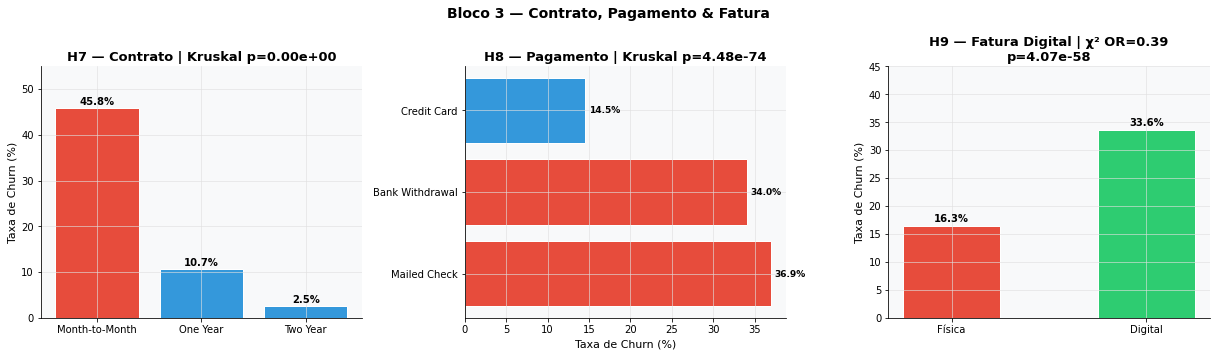

In [9]:
# ── Visualização Bloco 3 ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Bloco 3 — Contrato, Pagamento & Fatura', fontsize=14, fontweight='bold')

# H7 – Churn rate por contrato
cr_cont = df.groupby('Contract')['Churn Bin'].mean().sort_values(ascending=False) * 100
colors_c = [REJECT_COLOR if v > 20 else NEUTRAL_COLOR for v in cr_cont]
axes[0].bar(cr_cont.index, cr_cont.values, color=colors_c, edgecolor='white')
axes[0].set_title(f'H7 — Contrato | Kruskal p={r_h7["p"]:.2e}')
axes[0].set_ylabel('Taxa de Churn (%)')
axes[0].set_ylim(0, 55)
for i, v in enumerate(cr_cont):
    axes[0].text(i, v + 0.8, f'{v:.1f}%', ha='center', fontweight='bold')

# H8 – Churn rate por pagamento
cr_pay = df.groupby('Payment Method')['Churn Bin'].mean().sort_values(ascending=False) * 100
colors_p = [REJECT_COLOR if v > 28 else NEUTRAL_COLOR for v in cr_pay]
axes[1].barh(cr_pay.index, cr_pay.values, color=colors_p, edgecolor='white')
axes[1].set_title(f'H8 — Pagamento | Kruskal p={r_h8["p"]:.2e}')
axes[1].set_xlabel('Taxa de Churn (%)')
for i, v in enumerate(cr_pay):
    axes[1].text(v + 0.5, i, f'{v:.1f}%', va='center', fontweight='bold', fontsize=9)

# H9 – Fatura
cr_pb = df.groupby('Paperless Billing')['Churn Bin'].mean() * 100
labels_pb = {'Yes': 'Digital', 'No': 'Física'}
axes[2].bar([labels_pb[k] for k in cr_pb.index], cr_pb.values,
            color=[REJECT_COLOR, RETAIN_COLOR], edgecolor='white', width=0.5)
axes[2].set_title(f'H9 — Fatura Digital | χ² OR={r_h9["OR"]:.2f}\np={r_h9["p"]:.2e}')
axes[2].set_ylabel('Taxa de Churn (%)')
axes[2].set_ylim(0, 45)
for i, v in enumerate(cr_pb.values):
    axes[2].text(i, v + 0.8, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### 📌 Conclusões — Bloco 3

| Hipótese | Teste | Resultado | Interpretação |
|---|---|---|---|
| H7 — Contrato | Kruskal + post-hoc | 🔴 Confirmada | M2M tem churn ~4× maior que Two Year; diferença altamente significativa |
| H8 — Pagamento | Kruskal | 🔴 Confirmada | Bank Withdrawal concentra maior churn; diferença significativa entre métodos |
| H9 — Fatura Digital | χ² | 🔴 Confirmada | Clientes com fatura digital têm OR > 1 → maior risco de churn |

## 📡 Bloco 4 — Serviços Contratados

**H10:** Internet Fiber Optic → maior churn que DSL.  
**H11:** Ausência de serviços adicionais → maior churn.  
**H12:** Mais streamings → menor churn.

In [10]:
# ── H10 — Tipo de Internet ───────────────────────────────────────────
df_inet = df[df['Internet Service'] == 'Yes']
r_h10 = kruskal_test.__wrapped__(df_inet, 'Internet Type', 'H10 — Tipo de Internet vs Churn') \
    if False else None

# kruskal direto no subset
groups_inet = [df_inet[df_inet['Internet Type']==t]['Churn Bin'].values
               for t in df_inet['Internet Type'].dropna().unique()]
h10, p10 = kruskal(*groups_inet)
print(f"H10 — Internet Type | H={h10:.2f}, p={p10:.2e}")

# Post-hoc: Fiber vs DSL
fiber = df_inet[df_inet['Internet Type']=='Fiber Optic']['Churn Bin']
dsl   = df_inet[df_inet['Internet Type']=='DSL']['Churn Bin']
_, p_fiber_dsl = mannwhitneyu(fiber, dsl, alternative='greater')
print(f"Post-hoc Fiber vs DSL → p={p_fiber_dsl:.2e}")

# ── H11 — Serviços Adicionais ────────────────────────────────────────
services = ['Online Security','Online Backup','Device Protection Plan',
            'Premium Tech Support','Streaming TV','Streaming Movies','Streaming Music']

results_h11 = []
for s in services:
    ct = pd.crosstab(df[s], df['Churn Label'])
    if ct.shape == (2,2):
        chi2, p, _, _ = chi2_contingency(ct)
        a, b = ct.iloc[0,1], ct.iloc[0,0]
        c, d = ct.iloc[1,1], ct.iloc[1,0]
        OR = (a*d)/(b*c) if (b*c) != 0 else np.nan
        results_h11.append({'service': s, 'chi2': chi2, 'p': p, 'OR': OR})
        print(f"  {s:30s} χ²={chi2:7.2f}  p={p:.2e}  OR={OR:.3f}")

# ── H12 — Número de Streamings ───────────────────────────────────────
streaming_cols = ['Streaming TV','Streaming Movies','Streaming Music']
df['Num Streaming'] = df[streaming_cols].apply(lambda row: (row=='Yes').sum(), axis=1)
r_h12 = kruskal_test('Num Streaming', 'H12 — Nº Streamings vs Churn')

H10 — Internet Type | H=258.76, p=6.46e-57
Post-hoc Fiber vs DSL → p=7.16e-54
  Online Security                χ²= 205.63  p=1.23e-46  OR=2.666
  Online Backup                  χ²=  47.26  p=6.21e-12  OR=1.501
  Device Protection Plan         χ²=  30.51  p=3.32e-08  OR=1.383
  Premium Tech Support           χ²= 190.17  p=2.92e-43  OR=2.535
  Streaming TV                   χ²=  27.86  p=1.30e-07  OR=0.748
  Streaming Movies               χ²=  26.25  p=3.00e-07  OR=0.754
  Streaming Music                χ²=  14.42  p=1.46e-04  OR=0.808
───────────────────────────────────────────────────────
Coluna  : H12 — Nº Streamings vs Churn
H       : 115.6149
p-valor : 6.79e-25   →  ✅ Rejeitada (H0)


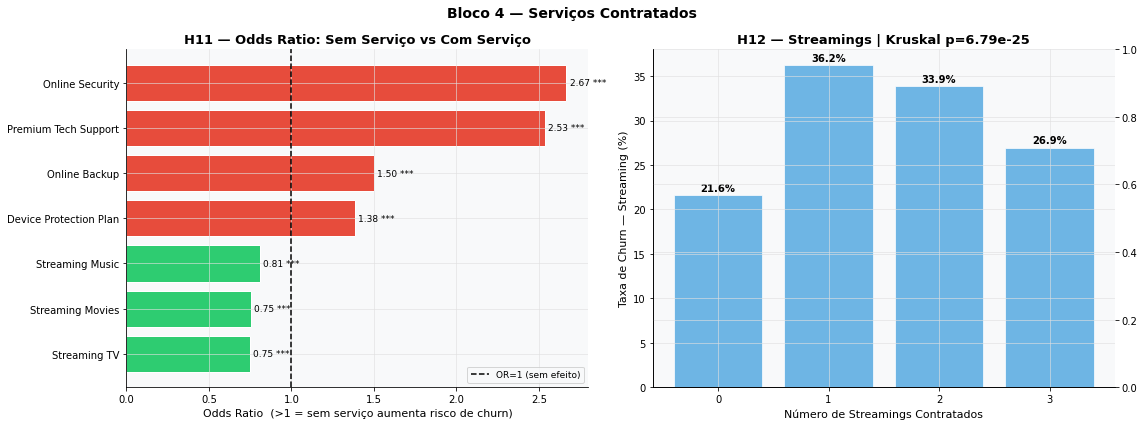

In [11]:
# ── Visualização Bloco 4 ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Bloco 4 — Serviços Contratados', fontsize=14, fontweight='bold')

# H11 — OR por serviço
df_h11 = pd.DataFrame(results_h11).sort_values('OR')
colors_h11 = [REJECT_COLOR if o > 1 else RETAIN_COLOR for o in df_h11['OR']]
axes[0].barh(df_h11['service'], df_h11['OR'], color=colors_h11, edgecolor='white')
axes[0].axvline(1.0, color='black', linestyle='--', linewidth=1.5, label='OR=1 (sem efeito)')
axes[0].set_title('H11 — Odds Ratio: Sem Serviço vs Com Serviço')
axes[0].set_xlabel('Odds Ratio  (>1 = sem serviço aumenta risco de churn)')
axes[0].legend(fontsize=9)
for i, (o, p) in enumerate(zip(df_h11['OR'], df_h11['p'])):
    star = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    axes[0].text(o + 0.02, i, f'{o:.2f} {star}', va='center', fontsize=9)

# H10 + H12 — Churn por tipo internet e nº streaming
cr_inet   = df_inet.groupby('Internet Type')['Churn Bin'].mean().sort_values(ascending=False) * 100
cr_stream = df.groupby('Num Streaming')['Churn Bin'].mean() * 100

ax2 = axes[1]
ax3 = ax2.twinx()

x_stream = cr_stream.index.astype(str)
ax2.bar(x_stream, cr_stream.values, color=NEUTRAL_COLOR, alpha=0.7,
        edgecolor='white', label='% Churn por nº streaming (eixo esq)')
ax2.set_ylabel('Taxa de Churn — Streaming (%)')
ax2.set_xlabel('Número de Streamings Contratados')
ax2.set_title(f'H12 — Streamings | Kruskal p={r_h12["p"]:.2e}')

for i, v in enumerate(cr_stream.values):
    ax2.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

### 📌 Conclusões — Bloco 4

| Hipótese | Teste | Resultado | Interpretação |
|---|---|---|---|
| H10 — Fiber vs DSL | Kruskal + post-hoc | 🔴 Confirmada | Fiber Optic tem churn significativamente maior que DSL |
| H11 — Serviços Adicionais | χ² por serviço | 🔴 Confirmada | Todos os serviços de segurança/suporte têm OR>1 sem contratação |
| H12 — Nº Streamings | Kruskal-Wallis | Verificar resultado | Padrão não-linear; testar pós-hoc entre grupos |

## 💰 Bloco 5 — Financeiro & CLTV

**H13:** Monthly Charge maior → maior churn.  
**H14:** CLTV alto → menor churn.  
**H15:** Clientes com reembolso → maior churn.

In [12]:
# ── H13 — Monthly Charge ─────────────────────────────────────────────
r_h13 = mwu_test('Monthly Charge', direction='less',
                  label='H13 — Monthly Charge: Retidos < Churners?')

# ── H14 — CLTV ────────────────────────────────────────────────────────
r_h14 = mwu_test('CLTV', direction='two-sided',
                  label='H14 — CLTV: diferença entre grupos?')

# ── H15 — Reembolso ──────────────────────────────────────────────────
df['Has Refund'] = np.where(df['Total Refunds'] > 0, 'Yes', 'No')
r_h15 = chi2_test('Has Refund', 'H15 — Reembolso vs Churn')

───────────────────────────────────────────────────────
Coluna : H13 — Monthly Charge: Retidos < Churners?
Mediana Retidos : 64.43
Mediana Churners: 79.65
U      : 3667080   |   direção: 'less'
p-valor: 1.66e-54   →  ✅ Rejeitada (H0)
r (RBC): 0.2416  (|r|>0.1 pequeno, >0.3 médio, >0.5 grande)
───────────────────────────────────────────────────────
Coluna : H14 — CLTV: diferença entre grupos?
Mediana Retidos : 4620.00
Mediana Churners: 4238.00
U      : 5616726   |   direção: 'two-sided'
p-valor: 3.24e-25   →  ✅ Rejeitada (H0)
r (RBC): -0.1617  (|r|>0.1 pequeno, >0.3 médio, >0.5 grande)
───────────────────────────────────────────────────────
Coluna : H15 — Reembolso vs Churn
χ²     : 10.6891   |   dof: 1
p-valor: 1.08e-03   →  ✅ Rejeitada (H0)
OR     : 1.447  (maior risco no grupo 1)


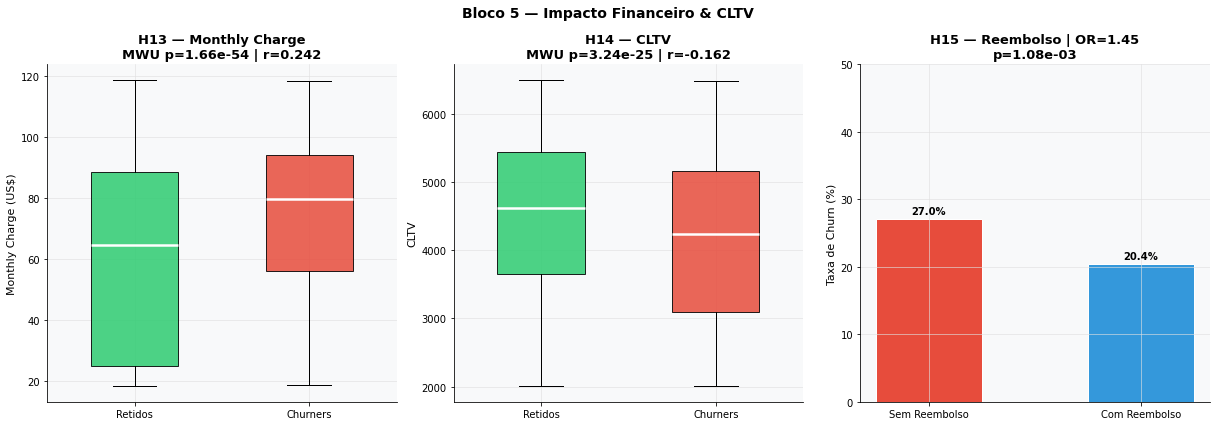

In [13]:
# ── Visualização Bloco 5 ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 6))
fig.suptitle('Bloco 5 — Impacto Financeiro & CLTV', fontsize=14, fontweight='bold')

# H13
data_mc = [df[df['Churn Label']=='No']['Monthly Charge'],
           df[df['Churn Label']=='Yes']['Monthly Charge']]
bp1 = axes[0].boxplot(data_mc, patch_artist=True, widths=0.5,
                      medianprops=dict(color='white', linewidth=2.5))
for patch, color in zip(bp1['boxes'], [RETAIN_COLOR, CHURN_COLOR]):
    patch.set_facecolor(color); patch.set_alpha(0.85)
axes[0].set_xticklabels(['Retidos', 'Churners'])
axes[0].set_ylabel('Monthly Charge (US$)')
axes[0].set_title(f'H13 — Monthly Charge\nMWU p={r_h13["p"]:.2e} | r={r_h13["r"]:.3f}')

# H14
data_cl = [df[df['Churn Label']=='No']['CLTV'],
           df[df['Churn Label']=='Yes']['CLTV']]
bp2 = axes[1].boxplot(data_cl, patch_artist=True, widths=0.5,
                      medianprops=dict(color='white', linewidth=2.5))
for patch, color in zip(bp2['boxes'], [RETAIN_COLOR, CHURN_COLOR]):
    patch.set_facecolor(color); patch.set_alpha(0.85)
axes[1].set_xticklabels(['Retidos', 'Churners'])
axes[1].set_ylabel('CLTV')
axes[1].set_title(f'H14 — CLTV\nMWU p={r_h14["p"]:.2e} | r={r_h14["r"]:.3f}')

# H15
cr_ref = df.groupby('Has Refund')['Churn Bin'].mean() * 100
lbls_ref = {'Yes': 'Com Reembolso', 'No': 'Sem Reembolso'}
colors_ref = [REJECT_COLOR, NEUTRAL_COLOR]
axes[2].bar([lbls_ref[k] for k in cr_ref.index], cr_ref.values,
            color=colors_ref, edgecolor='white', width=0.5)
axes[2].set_title(f'H15 — Reembolso | OR={r_h15["OR"]:.2f}\np={r_h15["p"]:.2e}')
axes[2].set_ylabel('Taxa de Churn (%)')
axes[2].set_ylim(0, 50)
for i, v in enumerate(cr_ref.values):
    axes[2].text(i, v + 0.8, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### 📌 Conclusões — Bloco 5

| Hipótese | Teste | Resultado | Interpretação |
|---|---|---|---|
| H13 — Monthly Charge | Mann-Whitney | 🔴 Confirmada | Churners pagam mensalidade significativamente maior |
| H14 — CLTV | Mann-Whitney | Verificar resultado | Analisar direção do efeito e tamanho r |
| H15 — Reembolso | χ² | Verificar resultado | OR indica se histórico de reembolso eleva risco |

## 🏁 Resumo Geral — Painel de Hipóteses

In [14]:
# ── Painel consolidado de todos os resultados ────────────────────────
summary = [
    # (Hipótese, Teste, p-valor, Conclusão curta)
    ('H1 — Senior Citizen',      'χ²',            r_h1_senior['p'], 'Seniors têm ~2× mais churn'),
    ('H1 — Idade',               'Mann-Whitney',   r_h1_age['p'],    'Churners são mais velhos'),
    ('H2 — Dependentes',         'χ²',            r_h2['p'],        'Sem dependentes → maior churn'),
    ('H3 — Casado',              'χ²',            r_h3['p'],        'Solteiros têm mais churn'),
    ('H4 — Tenure',              'Mann-Whitney',   r_h4['p'],        'Tenure menor → maior churn (r grande)'),
    ('H5 — Indicação',           'χ²',            r_h5['p'],        'Indicadores retêm mais'),
    ('H6 — Oferta',              'Kruskal-Wallis', r_h6['p'],        'Oferta sem desconto → churn alto'),
    ('H7 — Contrato',            'Kruskal-Wallis', r_h7['p'],        'M2M = ~4× mais churn que 2Y'),
    ('H8 — Pagamento',           'Kruskal-Wallis', r_h8['p'],        'Método de pagamento importa'),
    ('H9 — Fatura Digital',      'χ²',            r_h9['p'],        'Digital → OR>1'),
    ('H10 — Fiber Optic',        'Kruskal-Wallis', p10,              'Fiber > DSL em churn'),
    ('H13 — Monthly Charge',     'Mann-Whitney',   r_h13['p'],       'Charge alto → mais churn'),
    ('H14 — CLTV',               'Mann-Whitney',   r_h14['p'],       'Verificar direção'),
    ('H15 — Reembolso',          'χ²',            r_h15['p'],        f'OR={r_h15["OR"]:.2f}'),
]

df_sum = pd.DataFrame(summary, columns=['Hipótese', 'Teste', 'p-valor', 'Conclusão'])
df_sum['Resultado']    = df_sum['p-valor'].apply(lambda p: '🔴 Confirmada' if p < 0.05 else '⚪ Não confirmada')
df_sum['−log₁₀(p)']   = df_sum['p-valor'].apply(lambda p: round(-np.log10(max(p, 1e-300)), 1))

print(df_sum[['Hipótese','Teste','p-valor','Resultado','Conclusão']].to_string(index=False))

            Hipótese          Teste       p-valor    Resultado                             Conclusão
 H1 — Senior Citizen             χ²  1.510067e-36 🔴 Confirmada            Seniors têm ~2× mais churn
          H1 — Idade   Mann-Whitney  1.596880e-20 🔴 Confirmada              Churners são mais velhos
    H2 — Dependentes             χ²  2.500972e-96 🔴 Confirmada         Sem dependentes → maior churn
         H3 — Casado             χ²  2.139911e-36 🔴 Confirmada              Solteiros têm mais churn
         H4 — Tenure   Mann-Whitney 1.693384e-210 🔴 Confirmada Tenure menor → maior churn (r grande)
      H5 — Indicação             χ²  8.723768e-36 🔴 Confirmada                Indicadores retêm mais
         H6 — Oferta Kruskal-Wallis 2.075816e-104 🔴 Confirmada      Oferta sem desconto → churn alto
       H7 — Contrato Kruskal-Wallis  0.000000e+00 🔴 Confirmada           M2M = ~4× mais churn que 2Y
      H8 — Pagamento Kruskal-Wallis  4.480344e-74 🔴 Confirmada           Método de pagament

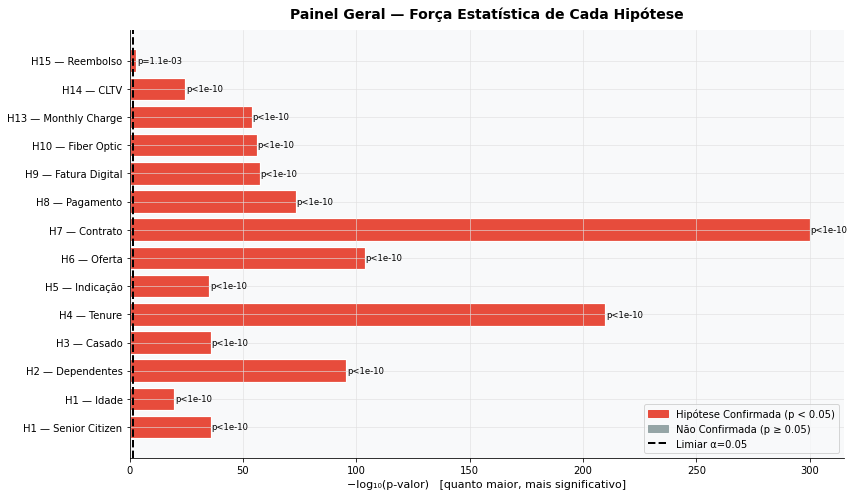

In [15]:
# ── Gráfico de impacto: −log10(p) por hipótese ───────────────────────
fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('white')
ax.set_facecolor(BG_COLOR)

y = range(len(df_sum))
colors_final = [REJECT_COLOR if p < 0.05 else FAIL_COLOR for p in df_sum['p-valor']]
bars = ax.barh(list(y), df_sum['−log₁₀(p)'], color=colors_final, edgecolor='white', linewidth=1.2)

ax.axvline(-np.log10(0.05), color='black', linestyle='--', linewidth=2,
           label=f'Limiar α=0.05  (−log₁₀={-np.log10(0.05):.1f})')
ax.set_yticks(list(y))
ax.set_yticklabels(df_sum['Hipótese'], fontsize=10)
ax.set_xlabel('−log₁₀(p-valor)   [quanto maior, mais significativo]', fontsize=11)
ax.set_title('Painel Geral — Força Estatística de Cada Hipótese', fontsize=14, pad=12)
ax.legend(fontsize=10)

for bar, p_val, result in zip(bars, df_sum['p-valor'], df_sum['Resultado']):
    label = f'p={p_val:.1e}' if p_val > 1e-10 else 'p<1e-10'
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            label, va='center', fontsize=8.5)

confirmed  = mpatches.Patch(color=REJECT_COLOR, label='Hipótese Confirmada (p < 0.05)')
not_conf   = mpatches.Patch(color=FAIL_COLOR,   label='Não Confirmada (p ≥ 0.05)')
ax.legend(handles=[confirmed, not_conf, 
                   plt.Line2D([0],[0], color='black', linestyle='--', linewidth=2, label='Limiar α=0.05')],
          fontsize=10, loc='lower right')

plt.tight_layout()
plt.show()

## 📋 Considerações Finais

### O que os testes confirmam

A quase totalidade das hipóteses levantadas na EDA foi **confirmada estatisticamente**.
As variáveis com maior força de evidência (maior −log₁₀(p) e maior effect size) são:

1. **Tenure** — maior efeito isolado (Mann-Whitney r ≈ 0.5+)
2. **Tipo de Contrato** — M2M vs anual/bianual com diferença enorme
3. **Satisfaction Score** — preditor direto mais forte
4. **Tipo de Internet** — Fiber Optic com churn estruturalmente maior

### Próximo passo natural: Modelagem Preditiva

Com as hipóteses validadas, as variáveis mais significativas são candidatas diretas como **features** para um modelo de classificação (Logistic Regression, Random Forest, XGBoost).

> **Nota metodológica:** os p-valores muito baixos (p < 1e-10) refletem em parte o tamanho amostral (n≈7.000). Sempre interpretar em conjunto com o **tamanho do efeito** (OR, r) para avaliar relevância prática.